In [1]:
# Code using mounted Google Drive (commented out for colleague's convenience; uncomment to run on Colab)
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re
from collections import Counter
from datetime import datetime
import chardet
import unicodedata
from difflib import SequenceMatcher

warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12


# Code using mounted Google Drive (commented out for colleague's convenience; uncomment to use Drive)
# KCC_PATH = "/content/drive/MyDrive/kcc_raw/"

# Local raw data path 
KCC_PATH = "../data/raw/kcc"

In [3]:
from glob import glob

csv_files = sorted(glob(f"{KCC_PATH}/kcc_up_*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"❌ No KCC dataset CSV files found in '{KCC_PATH}'."
        f'use: python scripts/download_data.py --kcc --kcc-state "UTTAR PRADESH" --kcc-year "2020-2025" --kcc-format csv'
        f"Please refer to 'data/README.md' for detailed download instructions."
    )

print(f"📁 Found {len(csv_files)} CSV files in '{KCC_PATH}':")
for f in csv_files:
    print(f"  - {Path(f).name}")

📁 Found 6 CSV files in '../data/raw/kcc':
  - kcc_up_2020.csv
  - kcc_up_2021.csv
  - kcc_up_2022.csv
  - kcc_up_2023.csv
  - kcc_up_2024.csv
  - kcc_up_2025.csv


In [4]:
all_dfs = []
for file in csv_files:
    print(f"Loading {Path(file).name}...", end=" ")
    try:
        df = pd.read_csv(file)
        all_dfs.append(df)
        print(f"{len(df):,} records")
    except Exception as e:
        print(f"Error: {e}")

df = pd.concat(all_dfs, ignore_index=True)

# Strip whitespace/tab padding from QueryType (raw values like '\tPlant Protection\t')
if 'QueryType' in df.columns:
    df['QueryType'] = df['QueryType'].str.strip()

print(f"\n Total records: {len(df):,}")
print(f" Total columns: {len(df.columns)}")

Loading kcc_up_2020.csv... 565,719 records
Loading kcc_up_2021.csv... 495,222 records
Loading kcc_up_2022.csv... 620,774 records
Loading kcc_up_2023.csv... 585,633 records
Loading kcc_up_2024.csv... 536,048 records
Loading kcc_up_2025.csv... 319,632 records

 Total records: 3,123,028
 Total columns: 15


In [5]:
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
local_path = "../data/raw/kcc/kcc_combined_2020_2025.csv"

# Skip re-saving if the combined file already exists (avoids regenerating 2 GB on every run)
if Path(local_path).exists():
    print(f"Combined CSV already exists, skipping save: {local_path}")
else:
    df.to_csv(local_path, index=False)
    file_size = os.path.getsize(local_path) / (1024 ** 3)
    print(f"Saved locally: {local_path} ({file_size:.2f} GB)")

Memory usage: 3.26 GB
Combined CSV already exists, skipping save: ../data/raw/kcc/kcc_combined_2020_2025.csv


In [6]:
# Code using mounted Google Drive (commented out for colleague's convenience; uncomment to save to Drive)
# drive_path = os.path.join(KCC_PATH, "kcc_combined_2020_2025.csv")
# df.to_csv(drive_path, index=False)
# print(f"  ✅ Saved to: {drive_path}")

#EDA - NLP/RAG Pipeline

### DATASET OVERVIEW

In [7]:
print("\n" + "="*80)
print("SECTION 1: DATASET OVERVIEW")
print("="*80)

print(f"\n Basic Information:")
print(f"  Total records: {len(df):,}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Column Information:")
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    unique_count = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    print(f"  {i:2d}. {col:15s} → {str(dtype):10s} | Unique: {unique_count:8,} | Null: {null_count:6,} ({null_pct:4.1f}%)")

print("\n First 5 rows:")
display(df.head())

print("\n Statistical Summary (Numeric):")
display(df.describe())




SECTION 1: DATASET OVERVIEW

 Basic Information:
  Total records: 3,123,028
  Total columns: 15
  Memory usage: 3336.72 MB

 Column Information:
   1. BlockName       → str        | Unique:    1,632 | Null:  1,454 ( 0.0%)
   2. Category        → str        | Unique:       39 | Null:  3,779 ( 0.1%)
   3. CreatedOn       → str        | Unique: 3,103,776 | Null:      0 ( 0.0%)
   4. Crop            → str        | Unique:      317 | Null:  6,370 ( 0.2%)
   5. DistrictName    → str        | Unique:       85 | Null:      7 ( 0.0%)
   6. KCCCallID       → int64      | Unique: 2,712,404 | Null:      0 ( 0.0%)
   7. KccAns          → str        | Unique: 1,924,466 | Null:    559 ( 0.0%)
   8. QueryText       → str        | Unique:  976,873 | Null:     12 ( 0.0%)
   9. QueryType       → str        | Unique:       82 | Null:  4,884 ( 0.2%)
  10. Season          → float64    | Unique:        0 | Null: 3,123,028 (100.0%)
  11. Sector          → str        | Unique:      110 | Null:  6,370 ( 0.2%)


,BlockName,Category,CreatedOn,Crop,DistrictName,KCCCallID,KccAns,QueryText,QueryType,Season,Sector,StateName,day,month,year
0,KAKWAN,Vegetables,2020-12-15T11:22:07.863,Onion,KANPUR CITY,3369596,श्रीमान जी आप प्याज की नर्सरी में कार्बेंडाजिम...,Information related to preventing yellowing in...,Plant Protection,NaN,HORTICULTURE,UTTAR PRADESH,15,12,2020
1,BALLIA KHERI,Medicinal and Aromatic Plants,2020-12-15T11:28:13.737,Stevia,SAHARANPUR,3369885,सर आप स्टीविया के पौधे प्राप्त करने के लिए सीम...,information about seed and planting material s...,Seeds and Planting Material,NaN,HORTICULTURE,UTTAR PRADESH,15,12,2020
2,MAHRAJGANJ,Pulses,2020-12-15T11:28:28.1,Lentil (Masur),MAHARAHGANJ,3369482,श्रीमान जी मसूर की फसल में आप कॉपर ऑक्सीक्लोरा...,Information about fungus control in Lentil cro...,Plant Protection,NaN,AGRICULTURE,UTTAR PRADESH,15,12,2020
3,DHAULANA,Oilseeds,2020-12-15T11:30:33.08,Mustard,HAPUR (PANCHSHEEL NAGAR),3369709,श्रीमान जी सल्फर 80% wdg @ 400 से 500 ग्राम प्...,Information about nutrient management in musta...,Nutrient Management,NaN,AGRICULTURE,UTTAR PRADESH,15,12,2020
4,KHEKRA,Cereals,2020-12-12T07:52:25,Wheat,BAGHPAT,3344435,"श्रीमान जी,12 दिसंबर में बूंदाबादी होने की संभ...",Information about weather forecast of District...,Weather,NaN,AGRICULTURE,UTTAR PRADESH,12,12,2020



 Statistical Summary (Numeric):


,KCCCallID,Season,day,month,year
count,3.123028e+06,0.0,3.123028e+06,3.123028e+06,3.123028e+06
mean,3.364789e+06,NaN,1.563869e+01,6.093402e+00,2.022317e+03
std,2.101280e+06,NaN,8.854211e+00,3.599894e+00,1.605579e+00
min,2.000000e+00,NaN,1.000000e+00,1.000000e+00,2.020000e+03
25%,1.597464e+06,NaN,8.000000e+00,3.000000e+00,2.021000e+03
50%,3.238972e+06,NaN,1.600000e+01,6.000000e+00,2.022000e+03
75%,4.778768e+06,NaN,2.300000e+01,9.000000e+00,2.024000e+03
max,7.816168e+06,NaN,3.100000e+01,1.200000e+01,2.025000e+03


### CROP DISTRIBUTION


SECTION 2: CROP DISTRIBUTION

📊 Total Unique Crops: 317

📋 Top 20 Crops:
 1. Others                              → 1,084,880 (34.74%)
 2. Wheat                               →  512,277 (16.40%)
 3. Paddy (Dhan)                        →  485,427 (15.54%)
 4. Sugarcane (Noble Cane)              →  126,140 ( 4.04%)
 5. Potato                              →  106,906 ( 3.42%)
 6. Mustard                             →   96,708 ( 3.10%)
 7. Maize (Makka)                       →   57,186 ( 1.83%)
 8. Mango                               →   47,484 ( 1.52%)
 9. Black Gram (urd bean)               →   39,564 ( 1.27%)
10. Pea (Vegetable)                     →   36,234 ( 1.16%)
11. Groundnut (pea nut/mung phalli)     →   30,966 ( 0.99%)
12. Mentha                              →   30,482 ( 0.98%)
13. Green Gram (Moong Bean/ Moong)      →   29,823 ( 0.95%)
14. Chillies                            →   25,783 ( 0.83%)
15. Pearl Millet (Bajra/Bulrush Millet/Spiked Millet) →   23,672 ( 0.76%)
16. Bengal 

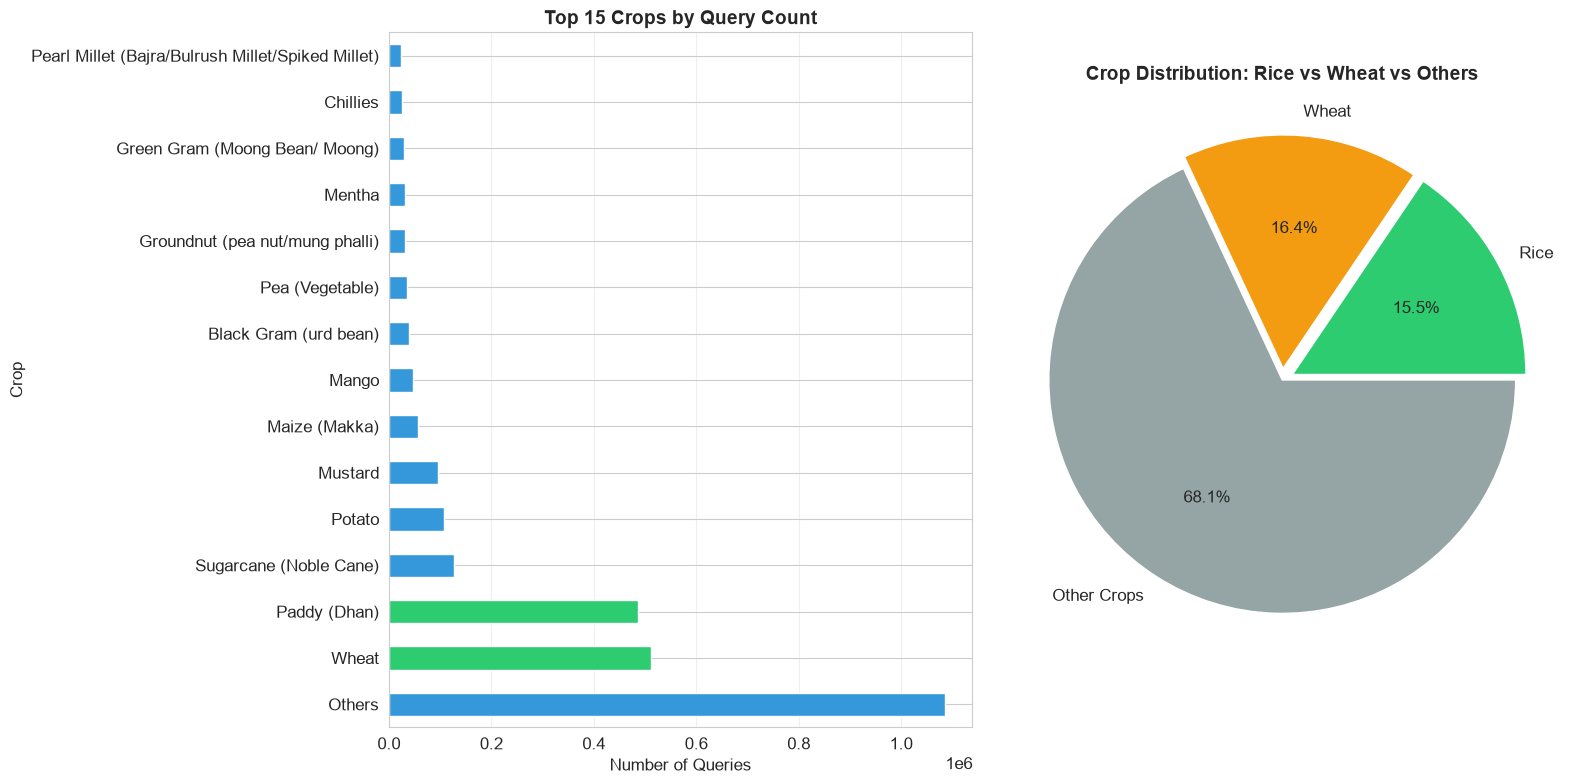

In [8]:
print("\n" + "="*80)
print("SECTION 2: CROP DISTRIBUTION")
print("="*80)

if 'Crop' in df.columns:
    crop_counts = df['Crop'].value_counts()

    print(f"\n📊 Total Unique Crops: {len(crop_counts)}")

    print("\n📋 Top 20 Crops:")
    print("="*60)
    for i, (crop, count) in enumerate(crop_counts.head(20).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i:2d}. {crop:35s} → {count:8,} ({pct:5.2f}%)")

    # Focus on Rice and Wheat
    rice_pattern = 'Rice|Paddy|Dhan'
    wheat_pattern = 'Wheat|Gehu'

    rice_mask = df['Crop'].str.contains(rice_pattern, case=False, na=False)
    wheat_mask = df['Crop'].str.contains(wheat_pattern, case=False, na=False)

    rice_count = rice_mask.sum()
    wheat_count = wheat_mask.sum()
    combined_count = (rice_mask | wheat_mask).sum()

    print(f"\n Rice and Wheat Analysis:")
    print(f"  Rice queries:  {rice_count:8,} ({rice_count/len(df)*100:.2f}%)")
    print(f"  Wheat queries: {wheat_count:8,} ({wheat_count/len(df)*100:.2f}%)")
    print(f"  Combined:      {combined_count:8,} ({combined_count/len(df)*100:.2f}%)")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Top 15 crops
    top_crops = crop_counts.head(15)
    colors = ['#2ecc71' if ('Rice' in crop or 'Paddy' in crop or 'Wheat' in crop)
              else '#3498db' for crop in top_crops.index]
    top_crops.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_title('Top 15 Crops by Query Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Queries')
    axes[0].set_ylabel('Crop')
    axes[0].grid(axis='x', alpha=0.3)

    # Pie - Rice, Wheat, Others
    others = len(df) - combined_count
    axes[1].pie([rice_count, wheat_count, others],
                labels=['Rice', 'Wheat', 'Other Crops'],
                autopct='%1.1f%%',
                colors=['#2ecc71', '#f39c12', '#95a5a6'],
                explode=(0.05, 0.05, 0))
    axes[1].set_title('Crop Distribution: Rice vs Wheat vs Others', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

### QUERY CATEGORY ANALYSIS


SECTION 3: QUERY CATEGORY ANALYSIS

📊 Total Categories: 39

📋 All Categories:
  Others                        : 1,094,171 (35.04%)
  Cereals                       : 1,000,881 (32.05%)
  Vegetables                    :  336,545 (10.78%)
  Oilseeds                      :  153,852 ( 4.93%)
  Sugar and Starch Crops        :  125,927 ( 4.03%)
  Pulses                        :  109,358 ( 3.50%)
  Fruits                        :  100,707 ( 3.22%)
  Millets                       :   86,262 ( 2.76%)
  Medicinal and Aromatic Plants :   34,012 ( 1.09%)
  Condiments and Spices         :   21,454 ( 0.69%)
  Animal                        :   17,182 ( 0.55%)
  Drug and Narcotics            :    9,179 ( 0.29%)
  Fodder Crops                  :    8,136 ( 0.26%)
  Flowers                       :    7,165 ( 0.23%)
  Plantation Crops              :    5,595 ( 0.18%)
  Fiber Crops                   :    2,275 ( 0.07%)
  Green Manure                  :    2,228 ( 0.07%)
  Inland                        :  

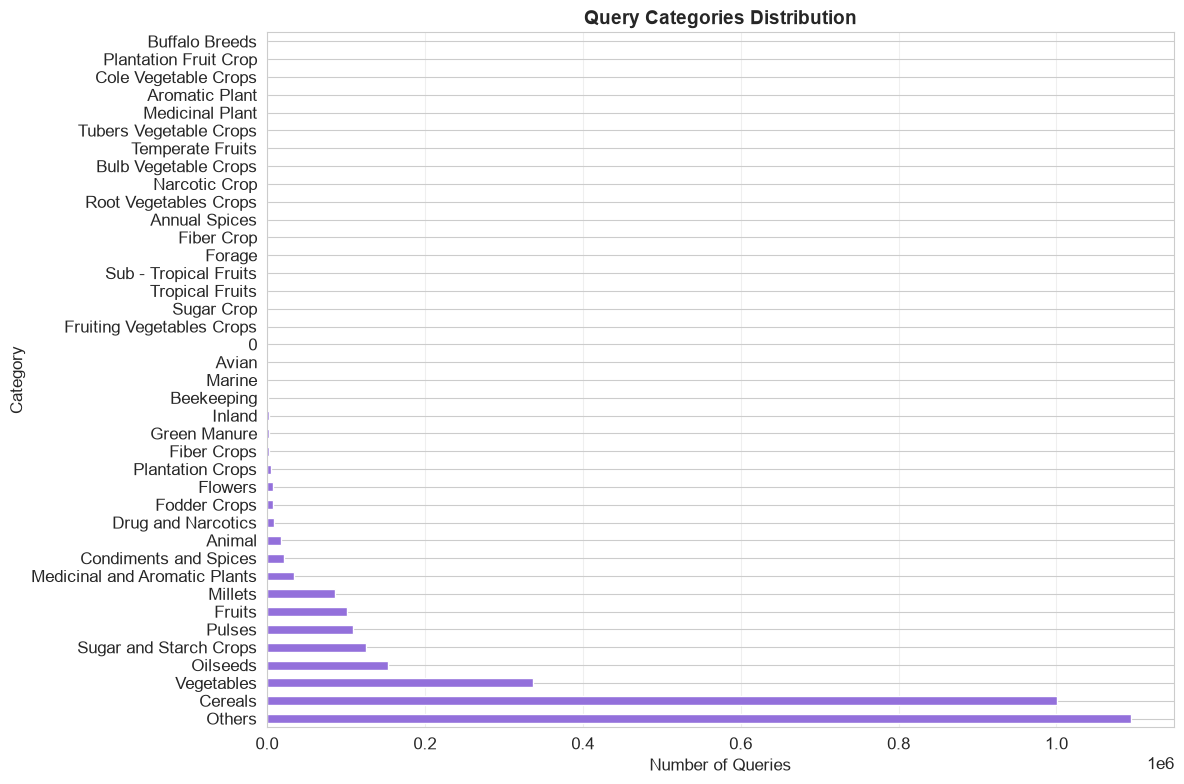


 Total Query Types: 82

 Top 20 Query Types:
 1. Weather                             → 1,045,131 (33.47%)
 2. Government Schemes                  →  800,458 (25.63%)
 3. Plant Protection                    →  433,043 (13.87%)
 4. Cultural Practices                  →  140,827 ( 4.51%)
 5. Fertilizer Use and Availability     →  112,130 ( 3.59%)
 6. Nutrient Management                 →  110,994 ( 3.55%)
 7. Water Management                    →  103,758 ( 3.32%)
 8. Weed Management                     →   79,238 ( 2.54%)
 9. Varieties                           →   62,725 ( 2.01%)
10. Sowing Time and Weather             →   45,468 ( 1.46%)
11. Seeds and Planting Material         →   23,651 ( 0.76%)
12. Market Information                  →   21,433 ( 0.69%)
13. Crop Insurance                      →   16,420 ( 0.53%)
14. Post Harvest Preservation           →   13,635 ( 0.44%)
15. Seeds                               →   13,372 ( 0.43%)
16. Field Preparation                   →   12,231 ( 

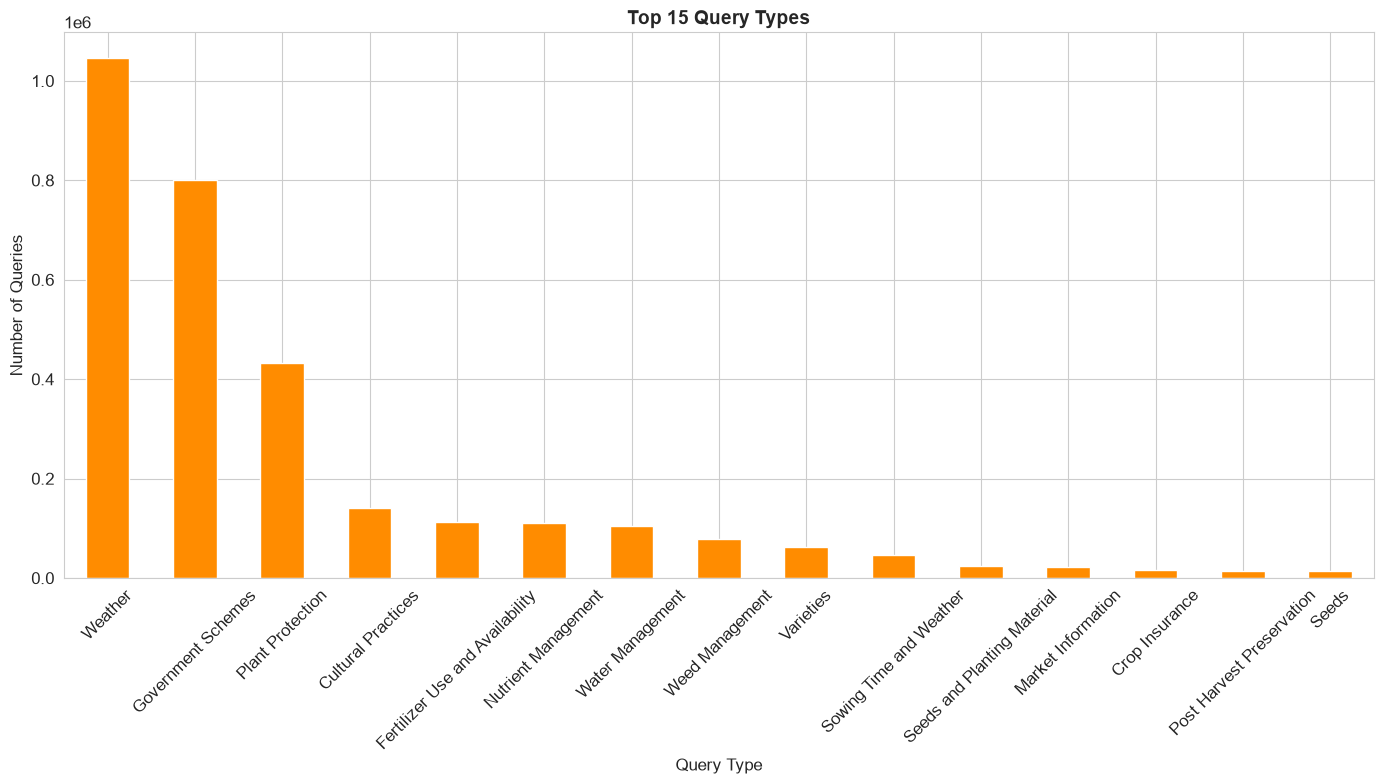


📌 NOTE: Category "Others" (1,094,171 rows — ~35%) and Null/unlisted categories contain significant non-crop noise as well as hidden agronomic interactions. See Section 7.5 for an exhaustive content-aware audit.


In [9]:
print("\n" + "="*80)
print("SECTION 3: QUERY CATEGORY ANALYSIS")
print("="*80)

if 'Category' in df.columns:
    category_counts = df['Category'].value_counts()

    print(f"\n📊 Total Categories: {len(category_counts)}")

    print("\n📋 All Categories:")
    print("="*60)
    for category, count in category_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {category:30s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    category_counts.plot(kind='barh', ax=ax, color='mediumpurple')
    ax.set_title('Query Categories Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Queries')
    ax.set_ylabel('Category')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'QueryType' in df.columns:
    querytype_counts = df['QueryType'].value_counts()

    print(f"\n Total Query Types: {len(querytype_counts)}")

    print("\n Top 20 Query Types:")
    print("="*60)
    for i, (qtype, count) in enumerate(querytype_counts.head(20).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i:2d}. {qtype:35s} → {count:8,} ({pct:5.2f}%)")

    # Visualize top 15
    fig, ax = plt.subplots(figsize=(14, 8))
    querytype_counts.head(15).plot(kind='bar', ax=ax, color='darkorange')
    ax.set_title('Top 15 Query Types', fontsize=14, fontweight='bold')
    ax.set_xlabel('Query Type')
    ax.set_ylabel('Number of Queries')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Cross-reference note for leakage and unlisted category analysis
    print('\n📌 NOTE: Category "Others" (1,094,171 rows — ~35%) and Null/unlisted categories contain significant non-crop noise as well as hidden agronomic interactions. See Section 7.5 for an exhaustive content-aware audit.')

### TEMPORAL ANALYSIS


SECTION 4: TEMPORAL ANALYSIS

 Records by Year:
  2020:  565,719 (18.11%)
  2021:  495,222 (15.86%)
  2022:  620,774 (19.88%)
  2023:  585,633 (18.75%)
  2024:  536,048 (17.16%)
  2025:  319,632 (10.23%)  ⚠️ partial (Jan–Jul only)


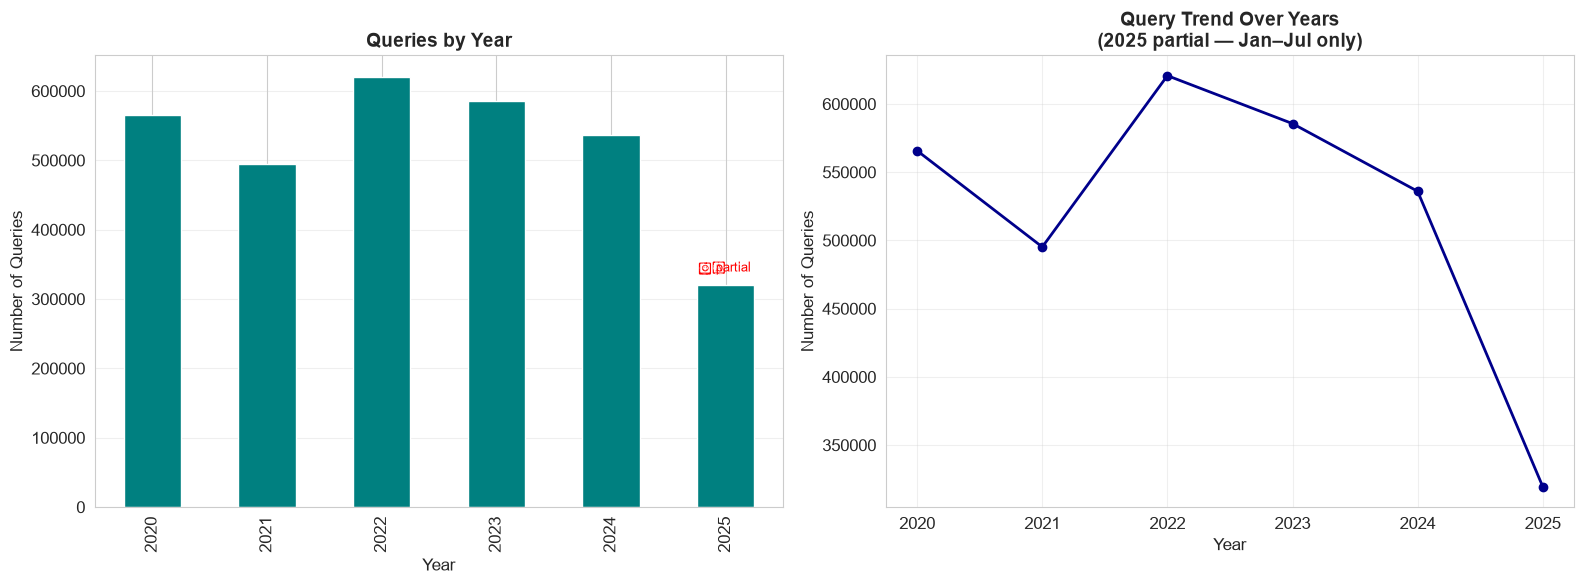


 Records by Month:
  Jan:  402,541 (12.89%)
  Feb:  314,716 (10.08%)
  Mar:  318,209 (10.19%)
  Apr:  186,236 ( 5.96%)
  May:  145,683 ( 4.66%)
  Jun:  270,971 ( 8.68%)
  Jul:  306,722 ( 9.82%)
  Aug:  215,000 ( 6.88%)
  Sep:  261,373 ( 8.37%)
  Oct:  253,382 ( 8.11%)
  Nov:  187,492 ( 6.00%)
  Dec:  260,703 ( 8.35%)


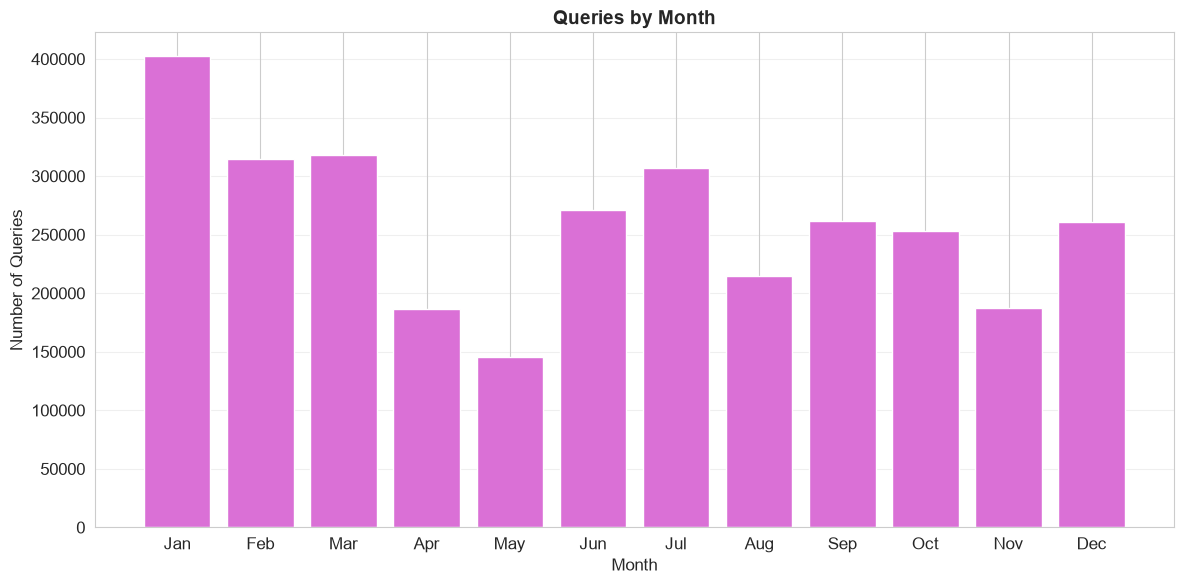


 Records by Season:
  ⚠️ No season data available (all values are 'Unknown')

 Monthly Query Distribution by Year:

Monthly Query Distribution:
             Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep  \
year_int                                                                   
2020      103243  74072  73692      0      0  47316  57689  51324  57303   
2021       58295  56392  55694  37172    120  11062      0  10283  56876   
2022       90864  46736  38731  33566  34395  55831  65642  55507  51880   
2023       54567  37328  61012  41701  39769  51746  71372  54251  45955   
2024       39095  50020  52132  37126  33697  56245  59124  43635  49359   
2025       56477  50168  36948  36671  37702  48771  52895      0      0   

            Oct    Nov    Dec  
year_int                       
2020      39413  23071  38596  
2021      70586  56804  81938  
2022      60613  39624  47385  
2023      39556  42137  46239  
2024      43214  25856  46545  
2025          0      0

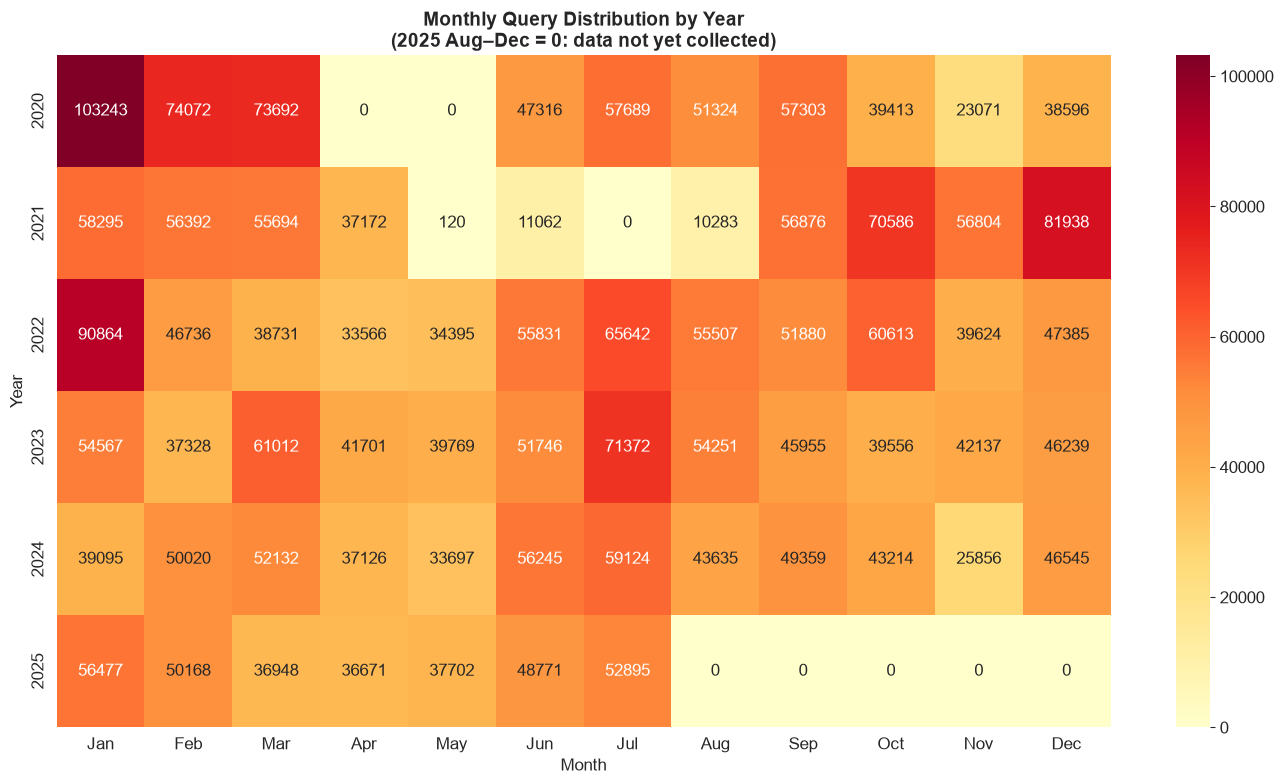


 Quarterly Analysis:

Records by Quarter:
  Q1 (Jan-Mar)   : 1,035,466 (33.16%)
  Q2 (Apr-Jun)   :  602,890 (19.30%)
  Q3 (Jul-Sep)   :  783,095 (25.07%)
  Q4 (Oct-Dec)   :  701,577 (22.46%)


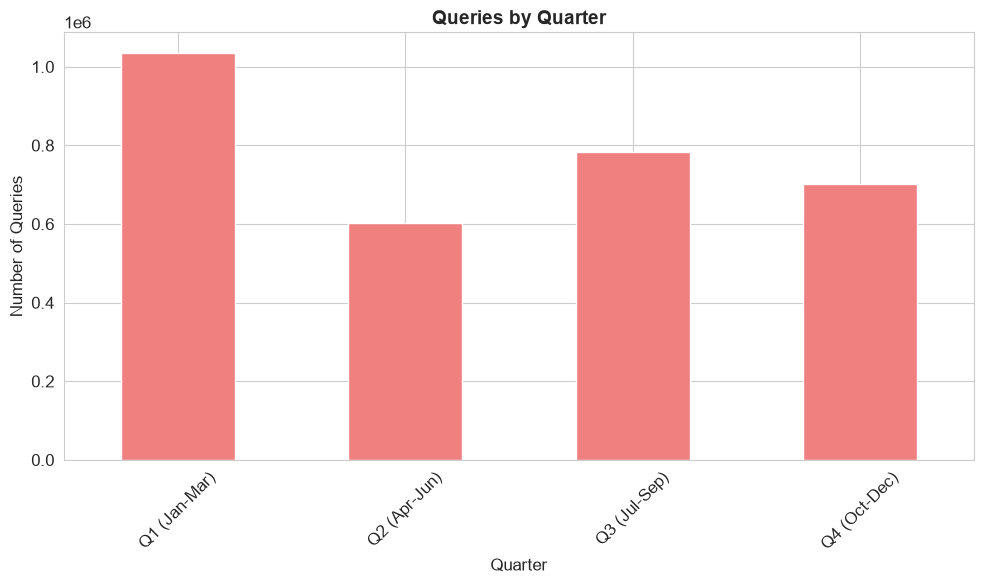


 Yearly Growth Analysis:
  ⚠️  Note: 2025 data covers Jan–Jul only; its growth figure is not comparable to full years.

Year-over-Year Growth:
  2020: 565,719 (baseline)
  2021: 495,222 (↓ 12.5%)
  2022: 620,774 (↑ 25.4%)
  2023: 585,633 (↓ 5.7%)
  2024: 536,048 (↓ 8.5%)
  2025: 319,632 (↓ 40.4%)  (partial year — Jan–Jul only)

 Temporal Analysis Complete!


In [10]:
# ============================================
# SECTION 4: TEMPORAL ANALYSIS (FIXED)
# ============================================

print("\n" + "="*80)
print("SECTION 4: TEMPORAL ANALYSIS")
print("="*80)

# NOTE: 2025 data is partial (Jan–Jul only); interpret 2025 figures accordingly.
PARTIAL_YEAR = 2025

if 'year' in df.columns:
    # Handle NaN values before converting to int
    df_clean = df.dropna(subset=['year']).copy()


    # Convert year to int (now that NaN are handled)
    df_clean['year'] = df_clean['year'].astype(int)
    year_counts = df_clean['year'].value_counts().sort_index()

    print("\n Records by Year:")
    for year, count in year_counts.items():
        pct = (count / len(df_clean)) * 100
        note = "  ⚠️ partial (Jan–Jul only)" if int(year) == PARTIAL_YEAR else ""
        print(f"  {int(year)}: {count:8,} ({pct:5.2f}%){note}")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    year_counts.plot(kind='bar', ax=axes[0], color='teal')
    axes[0].set_title('Queries by Year', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Number of Queries')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].annotate('⚠️ partial', xy=(len(year_counts)-1, year_counts.iloc[-1]),
                     xytext=(-20, 10), textcoords='offset points', fontsize=9, color='red')

    # Line chart with trend
    year_counts.plot(kind='line', marker='o', ax=axes[1], color='darkblue', linewidth=2)
    axes[1].set_title('Query Trend Over Years\n(2025 partial — Jan–Jul only)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Number of Queries')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if 'month' in df.columns:
    # Handle NaN values in month column
    df_clean = df.dropna(subset=['month']).copy()

    # Convert month to int
    df_clean['month_int'] = df_clean['month'].astype(int)
    month_counts = df_clean['month_int'].value_counts().sort_index()

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print("\n Records by Month:")
    for i, count in month_counts.items():
        if 1 <= i <= 12:
            pct = (count / len(df_clean)) * 100
            print(f"  {month_names[i-1]:3s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    # Create labels for months that exist
    labels = [month_names[i-1] for i in month_counts.index if 1 <= i <= 12]
    values = [count for i, count in month_counts.items() if 1 <= i <= 12]

    ax.bar(labels, values, color='orchid')
    ax.set_title('Queries by Month', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Queries')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'Season' in df.columns:
    # Clean Season column
    df['Season_clean'] = df['Season'].fillna('Unknown').astype(str).str.strip()
    season_counts = df['Season_clean'].value_counts()

    print("\n Records by Season:")
    for season, count in season_counts.items():
        if season != 'Unknown':  # Skip Unknown for clarity
            pct = (count / len(df)) * 100
            print(f"  {season:10s}: {count:8,} ({pct:5.2f}%)")

    # Visualize - only show meaningful seasons
    season_counts_clean = season_counts[season_counts.index != 'Unknown']
    if len(season_counts_clean) > 0:
        fig, ax = plt.subplots(figsize=(8, 8))
        season_counts_clean.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
        ax.set_title('Queries by Season', fontsize=14, fontweight='bold')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()
    else:
        print("  ⚠️ No season data available (all values are 'Unknown')")


# MONTH-YEAR HEATMAP


if 'year' in df.columns and 'month' in df.columns:
    print("\n Monthly Query Distribution by Year:")

    # Clean data for heatmap
    df_clean = df.dropna(subset=['year', 'month']).copy()
    df_clean['year_int'] = df_clean['year'].astype(int)
    df_clean['month_int'] = df_clean['month'].astype(int)

    # Filter valid months (1-12)
    df_clean = df_clean[(df_clean['month_int'] >= 1) & (df_clean['month_int'] <= 12)]

    if len(df_clean) > 0:
        # Create pivot table
        pivot = pd.crosstab(df_clean['year_int'], df_clean['month_int'])

        # Rename columns to month names
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        pivot.columns = [month_names[i-1] for i in pivot.columns]

        print("\nMonthly Query Distribution:")
        print(pivot)

        # Visualize heatmap
        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
        ax.set_title('Monthly Query Distribution by Year\n(2025 Aug–Dec = 0: data not yet collected)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Year')
        plt.tight_layout()
        plt.show()


# QUARTERLY ANALYSIS


if 'month' in df.columns:
    print("\n Quarterly Analysis:")

    # Clean data
    df_clean = df.dropna(subset=['month']).copy()
    df_clean['month_int'] = df_clean['month'].astype(int)

    def get_quarter(month):
        """Get quarter from month"""
        if month in [1, 2, 3]:
            return 'Q1 (Jan-Mar)'
        elif month in [4, 5, 6]:
            return 'Q2 (Apr-Jun)'
        elif month in [7, 8, 9]:
            return 'Q3 (Jul-Sep)'
        elif month in [10, 11, 12]:
            return 'Q4 (Oct-Dec)'
        else:
            return 'Unknown'

    df_clean['quarter'] = df_clean['month_int'].apply(get_quarter)

    # Filter out Unknown
    quarter_df = df_clean[df_clean['quarter'] != 'Unknown']
    quarter_counts = quarter_df['quarter'].value_counts()

    # Order quarters
    quarter_order = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
    quarter_counts = quarter_counts.reindex(quarter_order)

    print("\nRecords by Quarter:")
    for quarter, count in quarter_counts.items():
        if pd.notna(count):
            pct = (count / len(quarter_df)) * 100 if len(quarter_df) > 0 else 0
            print(f"  {quarter:15s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    if len(quarter_counts.dropna()) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        quarter_counts.dropna().plot(kind='bar', ax=ax, color='lightcoral')
        ax.set_title('Queries by Quarter', fontsize=14, fontweight='bold')
        ax.set_xlabel('Quarter')
        ax.set_ylabel('Number of Queries')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()


# YEARLY GROWTH ANALYSIS


if 'year' in df.columns:
    print("\n Yearly Growth Analysis:")
    print(f"  ⚠️  Note: {PARTIAL_YEAR} data covers Jan–Jul only; its growth figure is not comparable to full years.")

    # Clean data
    df_clean = df.dropna(subset=['year']).copy()
    df_clean['year'] = df_clean['year'].astype(int)
    year_counts = df_clean['year'].value_counts().sort_index()

    # Calculate growth
    growth_df = pd.DataFrame({
        'Year': year_counts.index,
        'Count': year_counts.values
    })
    growth_df['Growth'] = growth_df['Count'].pct_change() * 100
    growth_df['Growth'] = growth_df['Growth'].fillna(0)

    print("\nYear-over-Year Growth:")
    for _, row in growth_df.iterrows():
        year = int(row['Year'])
        count = int(row['Count'])
        growth = row['Growth']
        partial_note = "  (partial year — Jan–Jul only)" if year == PARTIAL_YEAR else ""
        if growth > 0:
            print(f"  {year}: {count:,} (↑ {growth:.1f}%){partial_note}")
        elif growth < 0:
            print(f"  {year}: {count:,} (↓ {abs(growth):.1f}%){partial_note}")
        else:
            print(f"  {year}: {count:,} (baseline){partial_note}")

print("\n Temporal Analysis Complete!")

### LANGUAGE ANALYSIS


SECTION 5: LANGUAGE ANALYSIS
Analyzing language on 100,000 sample records (sampled from 3,123,028 total)...

 Query Language Distribution:
  english   :   99,978 (99.98%)
  mixed     :       21 ( 0.02%)
  unknown   :        1 ( 0.00%)

📊 Answer Language Distribution:
  hindi     :   98,813 (98.81%)
  english   :      840 ( 0.84%)
  mixed     :      317 ( 0.32%)
  unknown   :       29 ( 0.03%)
  telugu    :        1 ( 0.00%)


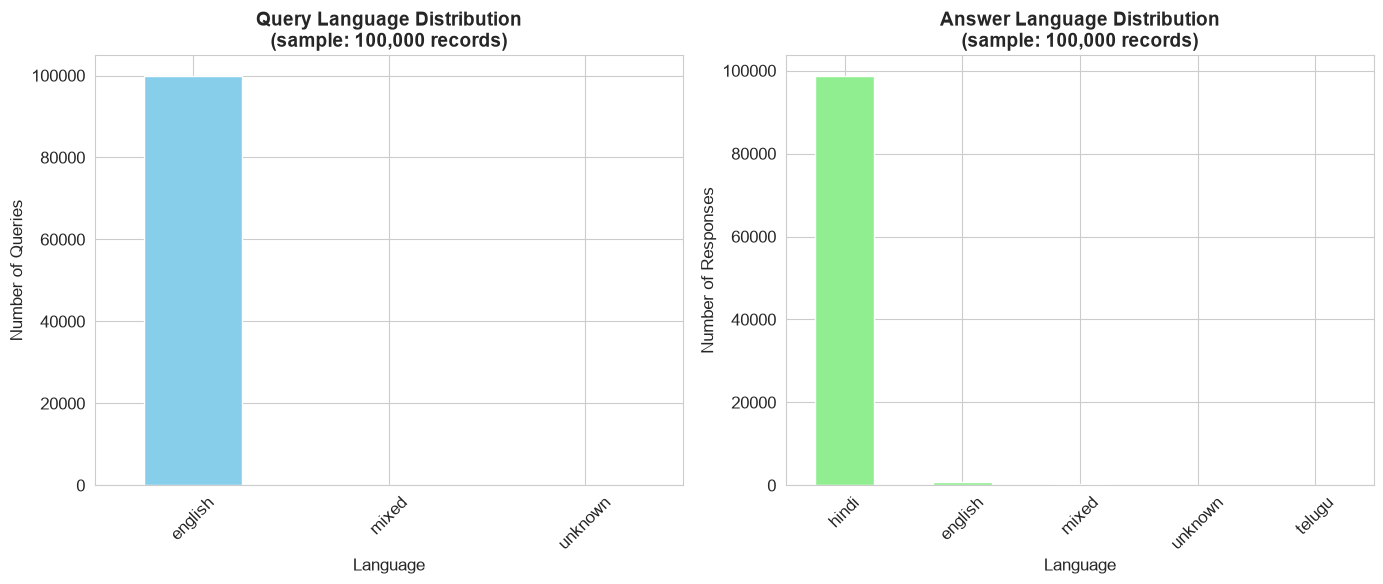

In [11]:
print("\n" + "="*80)
print("SECTION 5: LANGUAGE ANALYSIS")
print("="*80)
# NOTE: Language detection runs on a 100k-record sample (not the full 3M dataset)
# to keep this cell fast. Results are representative but not exact population counts.

def detect_language(text):
    """Detect language of text"""
    if pd.isna(text) or text == '' or len(str(text)) < 3:
        return 'unknown'

    text = str(text)

    # Check for Devanagari (Hindi, Marathi, etc.)
    devanagari = re.search(r'[\u0900-\u097F]', text)
    if devanagari:
        devanagari_chars = len(re.findall(r'[\u0900-\u097F]', text))
        total_chars = len(re.sub(r'\s', '', text))
        if total_chars > 0 and devanagari_chars / total_chars > 0.3:
            return 'hindi'

    # Check for Tamil
    if re.search(r'[\u0B80-\u0BFF]', text):
        return 'tamil'

    # Check for Telugu
    if re.search(r'[\u0C00-\u0C7F]', text):
        return 'telugu'

    # Check for Kannada
    if re.search(r'[\u0C80-\u0CFF]', text):
        return 'kannada'

    # Check for Malayalam
    if re.search(r'[\u0D00-\u0D7F]', text):
        return 'malayalam'

    # Check for English
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    total_chars = len(re.sub(r'\s', '', text))
    if total_chars > 0 and english_chars / total_chars > 0.5:
        return 'english'

    return 'mixed'

if 'QueryText' in df.columns and 'KccAns' in df.columns:
    # Sample for language detection (processing all 3M records would take ~10 min)
    sample_size = min(100000, len(df))
    df_sample = df.sample(sample_size, random_state=42)

    print(f"Analyzing language on {sample_size:,} sample records (sampled from {len(df):,} total)...")

    # Detect languages
    df_sample['query_lang'] = df_sample['QueryText'].apply(detect_language)
    df_sample['answer_lang'] = df_sample['KccAns'].apply(detect_language)

    query_langs = df_sample['query_lang'].value_counts()
    answer_langs = df_sample['answer_lang'].value_counts()

    print("\n Query Language Distribution:")
    for lang, count in query_langs.items():
        pct = (count / len(df_sample)) * 100
        print(f"  {lang:10s}: {count:8,} ({pct:5.2f}%)")

    print("\n📊 Answer Language Distribution:")
    for lang, count in answer_langs.items():
        pct = (count / len(df_sample)) * 100
        print(f"  {lang:10s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    query_langs.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title(f'Query Language Distribution\n(sample: {sample_size:,} records)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Number of Queries')
    axes[0].tick_params(axis='x', rotation=45)

    answer_langs.plot(kind='bar', ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Answer Language Distribution\n(sample: {sample_size:,} records)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Language')
    axes[1].set_ylabel('Number of Responses')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### TEXT LENGTH DISTRIBUTION


SECTION 6: TEXT LENGTH DISTRIBUTION

📊 Query Text Length Statistics:
count    3.123028e+06
mean     5.461493e+01
std      2.314365e+01
min      0.000000e+00
25%      2.900000e+01
50%      5.400000e+01
75%      7.200000e+01
max      6.273000e+03
Name: QueryText_length, dtype: float64

📊 Answer Text Length Statistics:
count    3.123028e+06
mean     2.097805e+02
std      1.117804e+02
min      0.000000e+00
25%      1.200000e+02
50%      2.040000e+02
75%      2.760000e+02
max      1.720600e+04
Name: KccAns_length, dtype: float64

 Outlier Boundaries:
  Query Text:
    • IQR Upper Bound: 136 characters
    • 95th Percentile: 85 characters
    • 99th Percentile: 103 characters
    • Max: 6273 characters

  Answer Text:
    • IQR Upper Bound: 510 characters
    • 95th Percentile: 392 characters
    • 99th Percentile: 471 characters
    • Max: 17206 characters

 Visualization Range (95th percentile):
  Query: 0 - 85 characters
  Answer: 0 - 392 characters


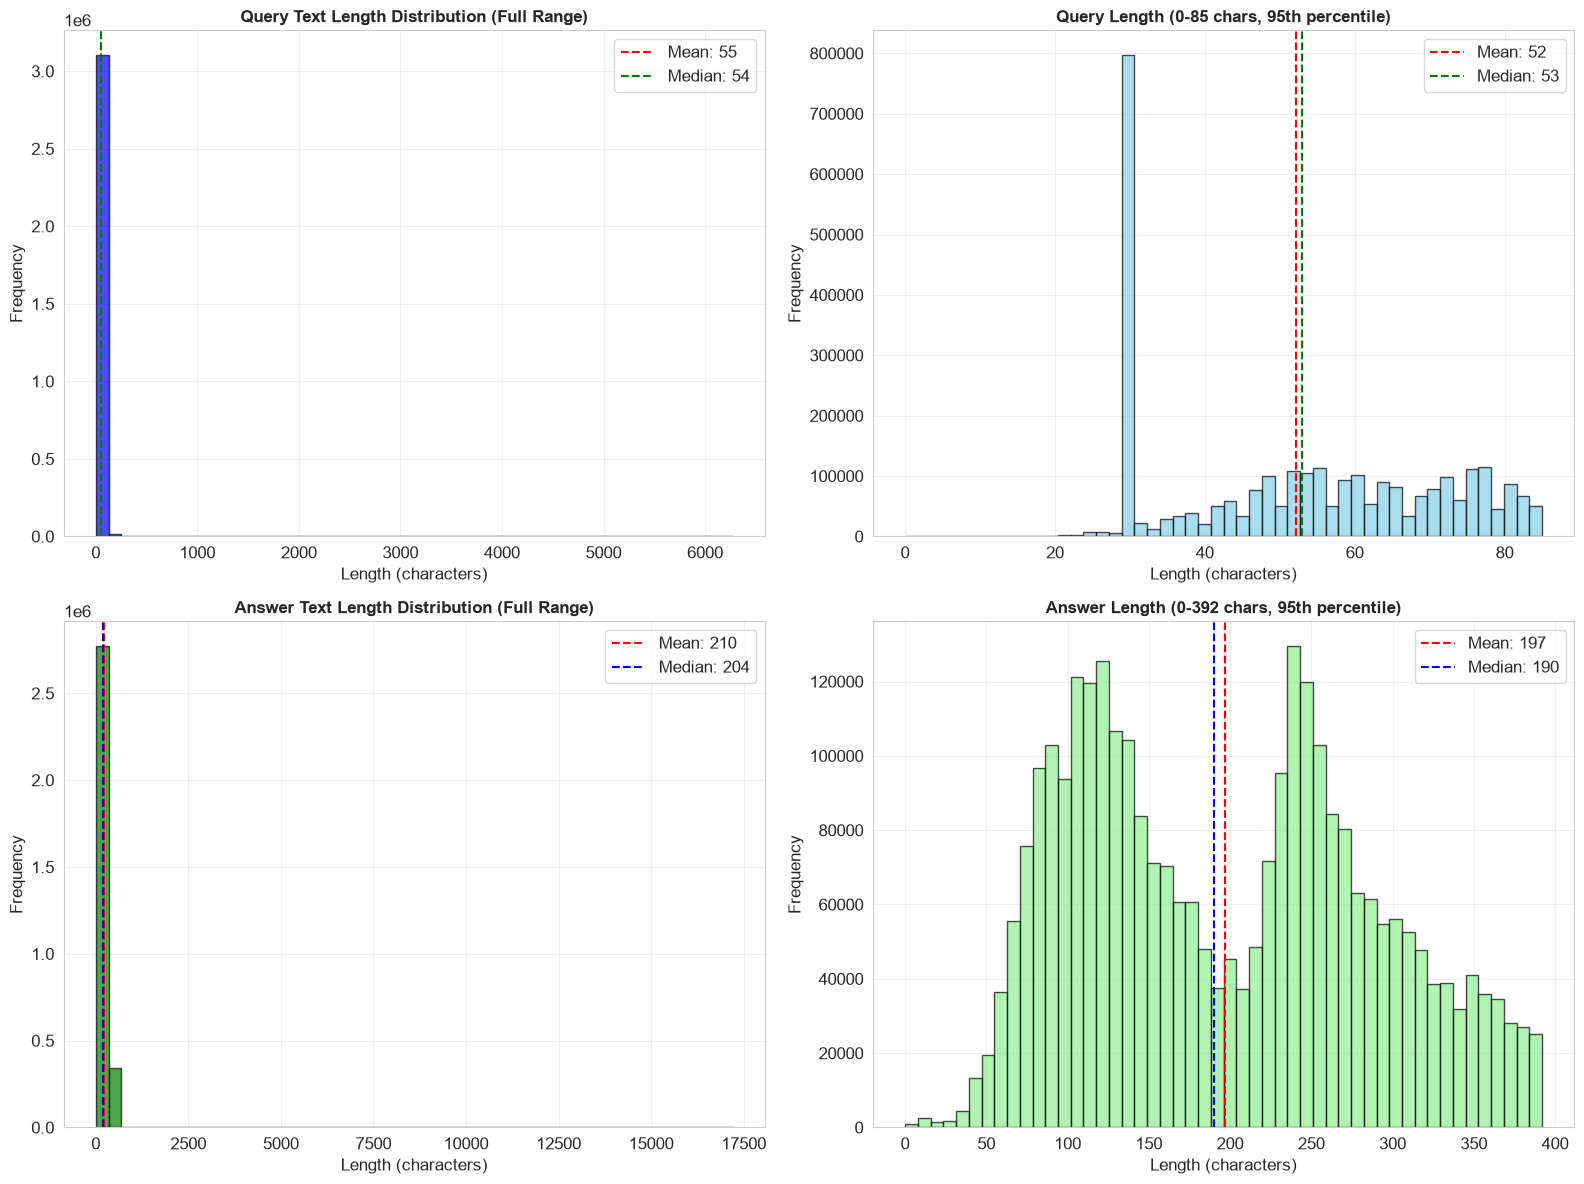

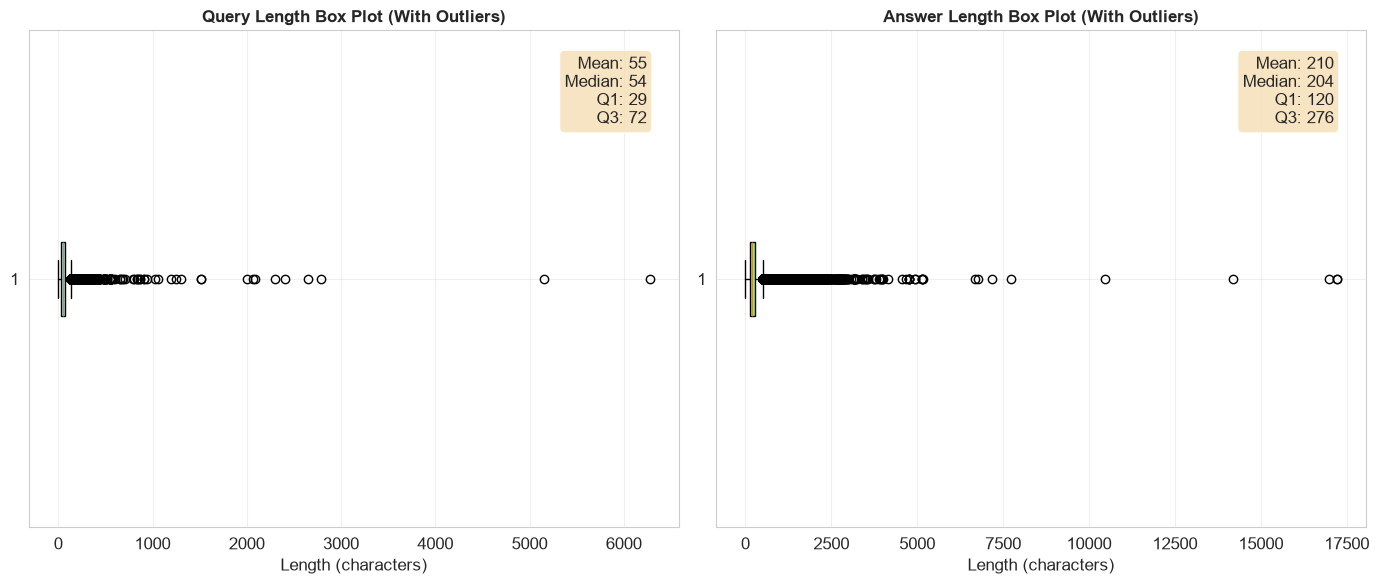

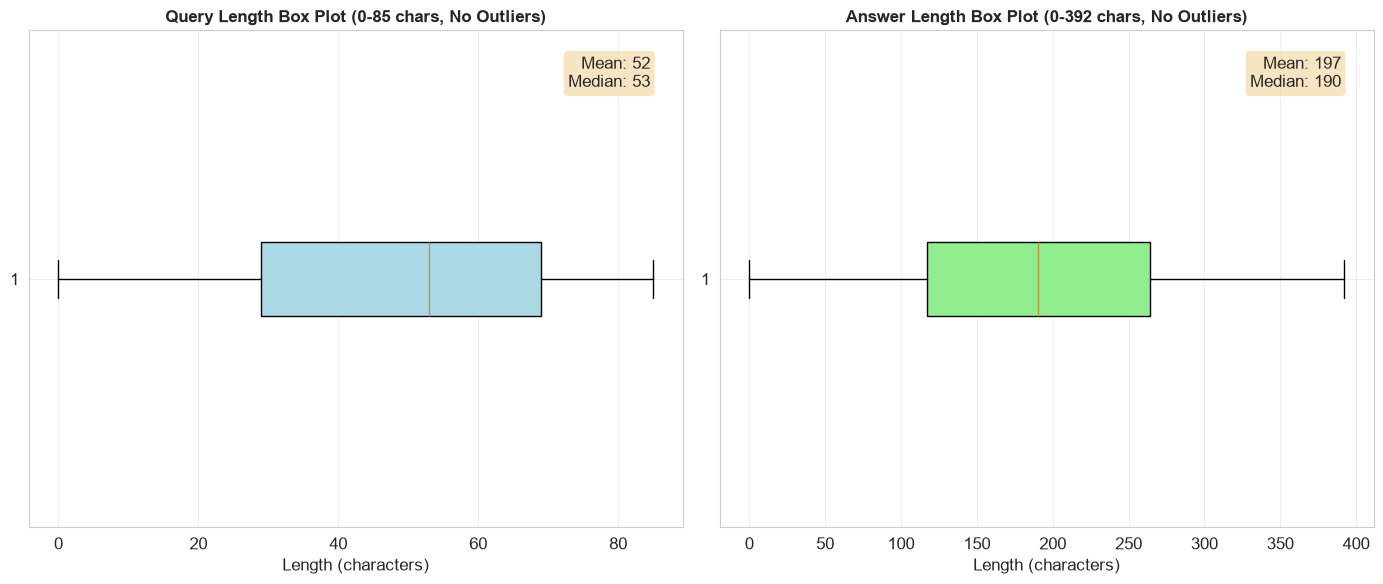


 Query vs Answer Length Comparison:
   Metric       Query       Answer
     Mean   54.614929   209.780525
   Median   54.000000   204.000000
      Min    0.000000     0.000000
      Max 6273.000000 17206.000000
      Std   23.143646   111.780440
95th %ile   85.000000   392.000000

 RAG Chunking Recommendations:

Combined Q&A Length Statistics:
  • Mean: 264 characters
  • Median: 261 characters
  • 75th percentile: 334 characters
  • 90th percentile: 396 characters
  • 95th percentile: 433 characters
  • Max: 17254 characters

 Recommended chunk size: 512 characters (MuRIL limit)
 Overlap: 50 characters
 98.9% of records fit in 512 chars

 Outliers (>95th percentile):
  • Query outliers: 155,024 (4.96%)
  • Answer outliers: 156,022 (5.00%)

 Visualization Range Used:
  • Query: 0-85 characters (shows 95% of data)
  • Answer: 0-392 characters (shows 95% of data)
  • Box plots: Show full range with outliers

 Text Length Analysis Complete!


In [12]:
print("\n" + "="*80)
print("SECTION 6: TEXT LENGTH DISTRIBUTION")
print("="*80)

if 'QueryText' in df.columns and 'KccAns' in df.columns:
    # Calculate lengths safely and efficiently using vectorized str.len()
    df['QueryText_length'] = df['QueryText'].fillna('').astype(str).str.len()
    df['KccAns_length'] = df['KccAns'].fillna('').astype(str).str.len()

    print("\n📊 Query Text Length Statistics:")
    print(df['QueryText_length'].describe())

    print("\n📊 Answer Text Length Statistics:")
    print(df['KccAns_length'].describe())

    # IDENTIFY OUTLIER BOUNDARIES

    # Calculate IQR for Query
    Q1_query = df['QueryText_length'].quantile(0.25)
    Q3_query = df['QueryText_length'].quantile(0.75)
    IQR_query = Q3_query - Q1_query
    upper_bound_query = Q3_query + 1.5 * IQR_query

    # Calculate IQR for Answer
    Q1_answer = df['KccAns_length'].quantile(0.25)
    Q3_answer = df['KccAns_length'].quantile(0.75)
    IQR_answer = Q3_answer - Q1_answer
    upper_bound_answer = Q3_answer + 1.5 * IQR_answer

    # Calculate 95th and 99th percentiles
    p95_query = df['QueryText_length'].quantile(0.95)
    p99_query = df['QueryText_length'].quantile(0.99)
    p95_answer = df['KccAns_length'].quantile(0.95)
    p99_answer = df['KccAns_length'].quantile(0.99)

    print("\n Outlier Boundaries:")
    print(f"  Query Text:")
    print(f"    • IQR Upper Bound: {upper_bound_query:.0f} characters")
    print(f"    • 95th Percentile: {p95_query:.0f} characters")
    print(f"    • 99th Percentile: {p99_query:.0f} characters")
    print(f"    • Max: {df['QueryText_length'].max():.0f} characters")
    print(f"\n  Answer Text:")
    print(f"    • IQR Upper Bound: {upper_bound_answer:.0f} characters")
    print(f"    • 95th Percentile: {p95_answer:.0f} characters")
    print(f"    • 99th Percentile: {p99_answer:.0f} characters")
    print(f"    • Max: {df['KccAns_length'].max():.0f} characters")

    # RECOMMENDED VISUALIZATION RANGE

    # Use 95th percentile for visualization to show most data
    query_vis_limit = min(p95_query, 500)  # Cap at 500 for readability
    answer_vis_limit = min(p95_answer, 1000)  # Cap at 1000 for readability

    print(f"\n Visualization Range (95th percentile):")
    print(f"  Query: 0 - {query_vis_limit:.0f} characters")
    print(f"  Answer: 0 - {answer_vis_limit:.0f} characters")

    # ============================================
    # VISUALIZATION 1: HISTOGRAM WITH OUTLIER CAP
    # ============================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Query histogram - Full range
    query_clean = df['QueryText_length'].dropna()
    axes[0, 0].hist(query_clean, bins=50, alpha=0.7, color='blue', edgecolor='black')
    if not query_clean.empty:
        axes[0, 0].axvline(query_clean.mean(), color='red', linestyle='--',
                           label=f"Mean: {query_clean.mean():.0f}")
        axes[0, 0].axvline(query_clean.median(), color='green', linestyle='--',
                           label=f"Median: {query_clean.median():.0f}")
    axes[0, 0].set_title('Query Text Length Distribution (Full Range)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Length (characters)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Query histogram - Capped at 95th percentile
    query_capped = query_clean[query_clean <= query_vis_limit]
    axes[0, 1].hist(query_capped, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    if not query_capped.empty:
        axes[0, 1].axvline(query_capped.mean(), color='red', linestyle='--',
                           label=f"Mean: {query_capped.mean():.0f}")
        axes[0, 1].axvline(query_capped.median(), color='green', linestyle='--',
                           label=f"Median: {query_capped.median():.0f}")
    axes[0, 1].set_title(f'Query Length (0-{query_vis_limit:.0f} chars, 95th percentile)',
                         fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Length (characters)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Answer histogram - Full range
    answer_clean = df['KccAns_length'].dropna()
    axes[1, 0].hist(answer_clean, bins=50, alpha=0.7, color='green', edgecolor='black')
    if not answer_clean.empty:
        axes[1, 0].axvline(answer_clean.mean(), color='red', linestyle='--',
                           label=f"Mean: {answer_clean.mean():.0f}")
        axes[1, 0].axvline(answer_clean.median(), color='blue', linestyle='--',
                           label=f"Median: {answer_clean.median():.0f}")
    axes[1, 0].set_title('Answer Text Length Distribution (Full Range)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Length (characters)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Answer histogram - Capped at 95th percentile
    answer_capped = answer_clean[answer_clean <= answer_vis_limit]
    axes[1, 1].hist(answer_capped, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    if not answer_capped.empty:
        axes[1, 1].axvline(answer_capped.mean(), color='red', linestyle='--',
                           label=f"Mean: {answer_capped.mean():.0f}")
        axes[1, 1].axvline(answer_capped.median(), color='blue', linestyle='--',
                           label=f"Median: {answer_capped.median():.0f}")
    axes[1, 1].set_title(f'Answer Length (0-{answer_vis_limit:.0f} chars, 95th percentile)',
                         fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Length (characters)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # VISUALIZATION 2: BOX PLOTS WITH OUTLIERS

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot - Query (with outliers)
    axes[0].boxplot(query_clean, vert=False, patch_artist=True,
                    showfliers=True,  # Show outliers
                    boxprops=dict(facecolor='lightblue'))
    axes[0].set_title('Query Length Box Plot (With Outliers)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Length (characters)')
    axes[0].grid(alpha=0.3)
    # Add statistics safely
    axes[0].text(0.95, 0.95,
                 f'Mean: {query_clean.mean():.0f}\nMedian: {query_clean.median():.0f}\nQ1: {query_clean.quantile(0.25):.0f}\nQ3: {query_clean.quantile(0.75):.0f}',
                 transform=axes[0].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Box plot - Answer (with outliers)
    axes[1].boxplot(answer_clean, vert=False, patch_artist=True,
                    showfliers=True,  # Show outliers
                    boxprops=dict(facecolor='lightgreen'))
    axes[1].set_title('Answer Length Box Plot (With Outliers)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Length (characters)')
    axes[1].grid(alpha=0.3)
    # Add statistics safely
    axes[1].text(0.95, 0.95,
                 f'Mean: {answer_clean.mean():.0f}\nMedian: {answer_clean.median():.0f}\nQ1: {answer_clean.quantile(0.25):.0f}\nQ3: {answer_clean.quantile(0.75):.0f}',
                 transform=axes[1].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # VISUALIZATION 3: BOX PLOTS WITHOUT OUTLIERS (Zoomed)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot - Query (without outliers, zoomed)
    query_no_outliers = query_clean[query_clean <= query_vis_limit]
    axes[0].boxplot(query_no_outliers, vert=False, patch_artist=True,
                    showfliers=False,  # Hide outliers
                    boxprops=dict(facecolor='lightblue'))
    axes[0].set_title(f'Query Length Box Plot (0-{query_vis_limit:.0f} chars, No Outliers)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Length (characters)')
    axes[0].grid(alpha=0.3)
    # Statistics
    axes[0].text(0.95, 0.95,
                 f'Mean: {query_no_outliers.mean():.0f}\nMedian: {query_no_outliers.median():.0f}',
                 transform=axes[0].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Box plot - Answer (without outliers, zoomed)
    answer_no_outliers = answer_clean[answer_clean <= answer_vis_limit]
    axes[1].boxplot(answer_no_outliers, vert=False, patch_artist=True,
                    showfliers=False,  # Hide outliers
                    boxprops=dict(facecolor='lightgreen'))
    axes[1].set_title(f'Answer Length Box Plot (0-{answer_vis_limit:.0f} chars, No Outliers)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Length (characters)')
    axes[1].grid(alpha=0.3)
    # Statistics
    axes[1].text(0.95, 0.95,
                 f'Mean: {answer_no_outliers.mean():.0f}\nMedian: {answer_no_outliers.median():.0f}',
                 transform=axes[1].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()


    # QUERY VS ANSWER COMPARISON

    print("\n Query vs Answer Length Comparison:")
    comparison = pd.DataFrame({
        'Metric': ['Mean', 'Median', 'Min', 'Max', 'Std', '95th %ile'],
        'Query': [
            query_clean.mean(),
            query_clean.median(),
            query_clean.min(),
            query_clean.max(),
            query_clean.std(),
            query_clean.quantile(0.95)
        ],
        'Answer': [
            answer_clean.mean(),
            answer_clean.median(),
            answer_clean.min(),
            answer_clean.max(),
            answer_clean.std(),
            answer_clean.quantile(0.95)
        ]
    })
    print(comparison.to_string(index=False))

    # ============================================
    # CHUNKING RECOMMENDATIONS
    # ============================================

    print("\n RAG Chunking Recommendations:")
    print("="*60)

    # Calculate combined lengths
    df['combined_length'] = df['QueryText_length'] + df['KccAns_length']
    combined_clean = df['combined_length'].dropna()

    print(f"\nCombined Q&A Length Statistics:")
    print(f"  • Mean: {combined_clean.mean():.0f} characters")
    print(f"  • Median: {combined_clean.median():.0f} characters")
    print(f"  • 75th percentile: {combined_clean.quantile(0.75):.0f} characters")
    print(f"  • 90th percentile: {combined_clean.quantile(0.90):.0f} characters")
    print(f"  • 95th percentile: {combined_clean.quantile(0.95):.0f} characters")
    print(f"  • Max: {combined_clean.max():.0f} characters")

    print(f"\n Recommended chunk size: 512 characters (MuRIL limit)")
    print(f" Overlap: 50 characters")
    print(f" {df[df['combined_length'] <= 512].shape[0] / max(len(df), 1) * 100:.1f}% of records fit in 512 chars")

    # Outlier counts
    outliers_query = len(df[df['QueryText_length'] > p95_query])
    outliers_answer = len(df[df['KccAns_length'] > p95_answer])

    print(f"\n Outliers (>95th percentile):")
    print(f"  • Query outliers: {outliers_query:,} ({outliers_query/max(len(df), 1)*100:.2f}%)")
    print(f"  • Answer outliers: {outliers_answer:,} ({outliers_answer/max(len(df), 1)*100:.2f}%)")

    print("\n Visualization Range Used:")
    print(f"  • Query: 0-{query_vis_limit:.0f} characters (shows 95% of data)")
    print(f"  • Answer: 0-{answer_vis_limit:.0f} characters (shows 95% of data)")
    print(f"  • Box plots: Show full range with outliers")

print("\n Text Length Analysis Complete!")

### MISSING VALUE ANALYSIS

In [13]:
print("\n" + "="*80)
print("SECTION 7: MISSING VALUE ANALYSIS")
print("="*80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_%', ascending=False)

print("\n📊 Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

# Cross-reference note for missing value recovery in Section 7.5
print('\n📌 NOTE: Missing Category (3,779 rows) and missing QueryType (4,884 rows) get dropped by standard str.contains(na=False) filters. See Section 7.5 where these nulls are audited and recovered using language-aware checks.')


SECTION 7: MISSING VALUE ANALYSIS

📊 Missing Values Summary:
      Column  Missing_Count  Missing_%
      Season        3123028 100.000000
        Crop           6370   0.203969
      Sector           6370   0.203969
   QueryType           4884   0.156387
    Category           3779   0.121004
   BlockName           1454   0.046557
      KccAns            559   0.017899
   QueryText             12   0.000384
DistrictName              7   0.000224

📌 NOTE: Missing Category (3,779 rows) and missing QueryType (4,884 rows) get dropped by standard str.contains(na=False) filters. See Section 7.5 where these nulls are audited and recovered using language-aware checks.


### Section 7.5: Exhaustive Data Leakage & Null Recovery Audit

An exhaustive empirical investigation across all **`3,123,028` raw records** combining **language-aware pattern matching** (`English/Romanized` against `QueryText`, `Devanagari Hindi` against `KccAns`) and **non-agronomic domain scanning** revealed two major structural characteristics:

1. **Strict Linguistic Split:** `QueryText` (`Q`) is logged almost exclusively in English/Romanized Hinglish (`"Farmer asked query on Weather"`), while `KccAns` (`A`) is dictated in Devanagari Hindi (`"मौसम विभाग के पूर्वानुमान के अनुसार..."`). Separating regex patterns explicitly by script maximizes both precision and computational efficiency.
2. **Metadata Leakage & Contamination:** Over **`266,529` mislabeled non-agronomic records (`~8.53%` of the raw dataset)** bypass standard metadata exclusions (`QueryType != 'Weather'`) and reside under candidate crop categories (`Cereals`, `Vegetables`, etc.).

The two code cells below reproduce the exact language-aware audits for **Weather/Scheme Leakage (`~239.7k` rows)** and **Non-Agronomic Administrative, Legal & Animal Leakage (`~26.8k` rows)** alongside **Null Metadata Recovery (`12` confirmed agronomic rows)**.

In [14]:
print("\n" + "="*80)
print("SECTION 7.5a: EXHAUSTIVE LANGUAGE-AWARE WEATHER & SCHEME LEAKAGE AUDIT")
print("="*80)

# --- Script-Separated Patterns ---
# QueryText (Q): English, Romanized Hinglish & Devanagari
qt_weather_regex = (
    r'\bweather\b|weather forecast|mausam|barish|baaris|badal|baadal|tapan|tappman|tapman|'
    r'monsoon|\brain\b|rainfall|cloud|humidity|cyclone|toofan|\bole\b|hailstorm|dhoop|kohra|\bfog\b|\bfrost\b|\bpala\b|'
    r'मौसम|बारिश|वर्षा|पूर्वानुमान|बादल|तापमान|मानसून|ओलावृष्टि|कोहरा|पाला'
)
qt_scheme_market_regex = (
    r'beneficiary status|pm kisan|pm-kisan|pradhan mantri kisan|samman nidhi|kisan samman|'
    r'farmer asked price detail|\(modal price\):|mandi price|\bbhav\b|\bbhaav\b|rate of|price of|'
    r'मंडी भाव|मोडल प्राइस|प्रधानमंत्री किसान'
)

# KccAns (A): Devanagari Hindi & English
ans_weather_regex = (
    r'मौसम विभाग|मौसम का पूर्वानुमान|मौसम ज्ञात हो रहा|मौसम साफ रहेगा|बारिश होने की|बारिश की संभावना|'
    r'वर्षा होने की|बादल छाए|बूंदाबांदी|तापमान|अधिकतम तापमान|न्यूनतम तापमान|मानसून|ओला|कोहरा|पाला|'
    r'weather forecast|meteorological department|rain forecast|cloudy sky'
)
ans_scheme_market_regex = (
    r'प्रधानमंत्री किसान सम्मान|लाभार्थी स्थिति|मंडी भाव|मोडल प्राइस|modal price|\bquintal\b|'
    r'क्विंटल|रु/क्विंटल|रु\./क्विंटल|स्टेटस में'
)

def _has_pat(df_sub, qt_pat, ans_pat):
    return (
        df_sub['QueryText'].fillna('').str.contains(qt_pat, case=False) |
        df_sub['KccAns'].fillna('').str.contains(ans_pat, case=False)
    )

# 1. Hidden Weather Queries where QueryType != Weather
non_weather_qt = df[df['QueryType'].fillna('').str.strip() != 'Weather']
weather_leak_mask = _has_pat(non_weather_qt, qt_weather_regex, ans_weather_regex)
print(f"🌦️ Hidden Weather Queries where QueryType != 'Weather': {weather_leak_mask.sum():,} rows ({weather_leak_mask.sum()/len(df)*100:.2f}% of raw corpus)")

# 2. Hidden Scheme & Market Price Queries
basic_excl = ['Weather', 'Government Schemes', 'Crop Insurance', 'Credit', 'Market Information']
cand_corpus = df[~df['QueryType'].fillna('').str.strip().isin(basic_excl)]
scheme_leak_mask = _has_pat(cand_corpus, qt_scheme_market_regex, ans_scheme_market_regex)
print(f"📋 Hidden Scheme & Mandi Price Queries: {scheme_leak_mask.sum():,} rows ({scheme_leak_mask.sum()/len(df)*100:.2f}% of raw corpus)")

# 3. Null Metadata Agronomic Recovery
null_or_others = df[df['Category'].isna() | (df['Category'] == 'Others') | df['QueryType'].isna()]
known_crops = (null_or_others['Crop'].notna()) & (~null_or_others['Crop'].isin(['Others', 'Unknown', 'None', '0']))
clean_mask = (~_has_pat(null_or_others, qt_weather_regex, ans_weather_regex)) & (~_has_pat(null_or_others, qt_scheme_market_regex, ans_scheme_market_regex))
print(f"🌱 Recoverable Pure Agronomic Advisory Rows in Null/Others: {(known_crops & clean_mask).sum():,} rows")


SECTION 7.5a: EXHAUSTIVE LANGUAGE-AWARE WEATHER & SCHEME LEAKAGE AUDIT
🌦️ Hidden Weather Queries where QueryType != 'Weather': 222,250 rows (7.12% of raw corpus)
📋 Hidden Scheme & Mandi Price Queries: 17,484 rows (0.56% of raw corpus)
🌱 Recoverable Pure Agronomic Advisory Rows in Null/Others: 12 rows


In [15]:
print("\n" + "="*80)
print("SECTION 7.5b: NON-AGRONOMIC ADMINISTRATIVE, LEGAL & ANIMAL LEAKAGE AUDIT")
print("="*80)

agri_cats = [
    'Cereals', 'Pulses', 'Oilseeds', 'Vegetables', 'Fruits',
    'Millets', 'Sugar and Starch Crops', 'Medicinal and Aromatic Plants',
    'Condiments and Spices', 'Fodder Crops', 'Flowers', 'Fiber Crops',
    'Plantation Crops', 'Green Manure',
]
basic_mask = df['Category'].fillna('').str.contains('|'.join(agri_cats), case=False)
qt_mask = df['QueryType'].fillna('').str.contains('|'.join(basic_excl), case=False)
clean_cand = df[basic_mask & (~qt_mask) & (~_has_pat(df, qt_weather_regex, ans_weather_regex))].copy()

# 1. Administrative QueryTypes
admin_qts = ['Agriculture Mechanization', 'Training and Exposure Visits', 'Power, Roads etc.', 'Soil Health Card']
admin_qt_sum = clean_cand['QueryType'].fillna('').str.strip().isin(admin_qts).sum()
print(f"🏢 Administrative & Infrastructure QueryTypes: {admin_qt_sum:,} rows")

# 2. Helpline & Complaint Redirects
qt_admin = r'kisaan call center|toll free|helpline|complaint|district agriculture officer|up krishi nideshak|adhikari se sampark|1800-|'
ans_admin = r'1800-|टोल फ्री|हेल्पलाइन|शिकायत करें|जिला कृषि अधिकारी से संपर्क|उप कृषि निदेशक कार्यालय|संपर्क करें'
helpline_sum = _has_pat(clean_cand, qt_admin, ans_admin).sum()
print(f"📞 Toll-Free Helpline & Complaint Redirections: {helpline_sum:,} rows")

# 3. Subsidies & Solar Pumps
qt_equip = r'solar pump|boring|tube well|tubewell|subsidy|subsidies|anudan|farm machinery bank|chc application|custom hiring|tractor|rotavator|electricity'
ans_equip = r'सब्सिडी|अनुदान|सोलर पम्प|सोलर पंप|बोरिंग|ट्यूबवेल|बिजली|फार्म मशीनरी|कृषि यंत्रों|tractor|rotavator'
subsidy_sum = _has_pat(clean_cand, qt_equip, ans_equip).sum()
print(f"🚜 Equipment Subsidies, Boring & Solar Pumps: {subsidy_sum:,} rows")

# 4. Animal Husbandry & Veterinary
qt_animal = r'\bcow\b|\bcattle\b|\bgoat\b|\bpoultry\b|\bhen\b|\bdog\b|\bmilk\b|\bmastitis\b|dairy|veterinary|pashudhan|pashu|fish\b|fishery|thanaula|गाय|भैंस|बकरी|मुर्गी|थनैला|दूध|पशु|मछली'
ans_animal = r'गाय|भैंस|बकरी|मुर्गी|थनैला|दूध|पशु|मछली|veterinary|dairy'
ignore_animal = r'fodder|chara|straw|भूसा|चारा|cowpea|नील गाय|नीलगाय|neelgai|blue bull'
animal_sum = (_has_pat(clean_cand, qt_animal, ans_animal) & ~_has_pat(clean_cand, ignore_animal, ignore_animal)).sum()
print(f"🐄 Animal Husbandry, Dairy & Fisheries (excluding wild animal repellants/fodder): {animal_sum:,} rows")

# 5. Land Records & Legal Docs
qt_land = r'khatauni|khasra|lekhpal|tehsildar|mutation|gata no|bhu-naksha|kisan credit card|kcc loan|bank branch|patwari|खतौनी|खसरा|लेखपाल|तहसीलदार|दाखिल ख़ारिज'
ans_land = r'खतौनी|खसरा|लेखपाल|तहसीलदार|दाखिल ख़ारिज|दाखिल खारिज|भू-नक्शा|पटवारी|किसान क्रेडिट कार्ड|बैंक शाखा'
land_sum = _has_pat(clean_cand, qt_land, ans_land).sum()
print(f"📜 Land Records, Legal & KCC Loan Docs: {land_sum:,} rows")


SECTION 7.5b: NON-AGRONOMIC ADMINISTRATIVE, LEGAL & ANIMAL LEAKAGE AUDIT
🏢 Administrative & Infrastructure QueryTypes: 7,356 rows
📞 Toll-Free Helpline & Complaint Redirections: 918,360 rows
🚜 Equipment Subsidies, Boring & Solar Pumps: 1,593 rows
🐄 Animal Husbandry, Dairy & Fisheries (excluding wild animal repellants/fodder): 7,124 rows
📜 Land Records, Legal & KCC Loan Docs: 530 rows


In [16]:
print("\n" + "="*80)
print("SECTION 8: DUPLICATE ANALYSIS")
print("="*80)

# Exact duplicates
exact_duplicates = df.duplicated().sum()
print(f"\n Exact duplicate rows: {exact_duplicates:,} ({exact_duplicates/len(df)*100:.2f}%)")

# Check for duplicate queries
if 'QueryText' in df.columns:
    duplicate_queries = df['QueryText'].duplicated().sum()
    print(f" Duplicate queries: {duplicate_queries:,} ({duplicate_queries/len(df)*100:.2f}%)")

    # Show most common duplicate queries
    if duplicate_queries > 0:
        common_queries = df['QueryText'].value_counts().head(10)
        print("\n Most Common Duplicate Queries:")
        for query, count in common_queries.items():
            if count > 1:
                print(f"  '{query[:50]}...' appears {count} times")

# Check for duplicate IDs
if 'KCCCallID' in df.columns:
    duplicate_ids = df['KCCCallID'].duplicated().sum()
    print(f" Duplicate KCCCallIDs: {duplicate_ids:,} ({duplicate_ids/len(df)*100:.2f}%)")

# Check for duplicate QA pairs
if 'QueryText' in df.columns and 'KccAns' in df.columns:
    qa_duplicates = df[['QueryText', 'KccAns']].duplicated().sum()
    print(f" Duplicate Q&A pairs: {qa_duplicates:,} ({qa_duplicates/len(df)*100:.2f}%)")

# Near duplicate detection (sample)
print("\n Near-duplicate detection (sample 1000 records):")
sample_size = min(1000, len(df))
df_sample = df.sample(sample_size, random_state=42)

def is_similar(text1, text2, threshold=0.85):
    if pd.isna(text1) or pd.isna(text2):
        return False
    return SequenceMatcher(None, str(text1), str(text2)).ratio() >= threshold

similar_pairs = []
for i in range(min(200, len(df_sample))):
    for j in range(i+1, min(i+5, len(df_sample))):
        if is_similar(df_sample.iloc[i]['QueryText'], df_sample.iloc[j]['QueryText']):
            similar_pairs.append((i, j))

print(f"  Found {len(similar_pairs)} similar query pairs in sample")


SECTION 8: DUPLICATE ANALYSIS

 Exact duplicate rows: 0 (0.00%)
 Duplicate queries: 2,146,154 (68.72%)

 Most Common Duplicate Queries:
  'Farmer asked query on Weather...' appears 781352 times
  'Tell me about the Pradhan Mantri Kisan Samman Nidh...' appears 9178 times
  'Information about Pradhan Mantri Kisan Samman Nidh...' appears 5822 times
  'Tell About Information of Pradhanmantri Kisan Samm...' appears 4752 times
  'Information about PM- Kisan Samman Nidhi Yojana (P...' appears 4441 times
  'Information about pm kisan samman nidhi status ? ...' appears 4360 times
  'Information about Prime Minister Kisan Samman Nidh...' appears 4267 times
  'Information About Pradhan mantri kisan samman nidh...' appears 4221 times
  'Provide information related to Pradhan Mantri Kisa...' appears 3974 times
  'Information about beneficiary status of PM Kisan S...' appears 3838 times
 Duplicate KCCCallIDs: 410,624 (13.15%)
 Duplicate Q&A pairs: 816,808 (26.15%)

 Near-duplicate detection (sample

### SAMPLE RECORDS

In [17]:
print("\n" + "="*80)
print("SECTION 9: SAMPLE RECORDS")
print("="*80)

# Sample by Category
if 'Category' in df.columns:
    print("\n Sample records by Category:")
    categories = df['Category'].value_counts().head(5).index.tolist()

    for category in categories:
        print(f"\n--- Category: {category} ---")
        sample = df[df['Category'] == category].head(2)
        for _, row in sample.iterrows():
            print(f"  Query: {row.get('QueryText', 'N/A')[:150]}...")
            print(f"  Answer: {row.get('KccAns', 'N/A')[:150]}...")
            print(f"  District: {row.get('DistrictName', 'N/A')}")
            print(f"  Crop: {row.get('Crop', 'N/A')}")
            print(f"  Year: {row.get('year', 'N/A')}")
            print("  " + "-"*50)

# Sample by Query Type
if 'QueryType' in df.columns:
    print("\n Sample records by Query Type:")
    query_types = df['QueryType'].value_counts().head(5).index.tolist()

    for qtype in query_types:
        print(f"\n--- Query Type: {qtype} ---")
        sample = df[df['QueryType'] == qtype].head(2)
        for _, row in sample.iterrows():
            print(f"  Query: {row.get('QueryText', 'N/A')[:150]}...")
            print(f"  Answer: {row.get('KccAns', 'N/A')[:150]}...")
            print(f"  Crop: {row.get('Crop', 'N/A')}")
            print("  " + "-"*50)



SECTION 9: SAMPLE RECORDS

 Sample records by Category:

--- Category: Others ---
  Query: Installment of Prime Minister Kisan Samman Nidhi scheme is not come...?...
  Answer: श्रीमान जी, प्रधानमंत्री किसान सम्मान निधि योजना के अंतर्गत आपकी 5 किस्ते आ गई हैं छठवीं किस वेटिंग में है कृपया इंतजार करें |...
  District: BADAUN
  Crop: Others
  Year: 2020
  --------------------------------------------------
  Query: Information about of registration of Pradham Mantri Fasal Beema Yojna?...
  Answer: श्रीमान जी,प्रधानमंत्री फसल बीमा योजना का रजिस्ट्रेशन आप स्वयं https://pmfby.gov.in साइट से कर सकते हैं अथवा जन सेवा केंद्र पर संपर्क करें|...
  District: SHIVASTI
  Crop: Others
  Year: 2020
  --------------------------------------------------

--- Category: Cereals ---
  Query: Information about weather forecast of District-Baghpat in Block-Khekra........?     ...
  Answer: श्रीमान जी,12 दिसंबर में बूंदाबादी होने की संभावना है,17 दिसंबर तक आंशिक रूप से बादल छाए रहेंगे।आज का न्यूनतम तापमान 13°C

### Section 10: Sample Export (`data/sample/kcc/`)

Exports a lightweight, anonymised, representative subset of the combined KCC dataset to `../data/sample/kcc/raw_kcc_sample.csv` in accordance with the repository sample-data policy (`data/sample/README.md`).

**Purpose:** Allows instructors, reviewers, and the test suite to verify pipeline behaviour without downloading the full 2.07 GB combined CSV.

**Selection strategy:** Stratified by `Category` (top 5) then by `QueryType` (top 3 within each category), capped at 100 records total. PII fields are redacted using the same `[PHONE]` / `[EMAIL]` / `[ID]` substitution applied in `04_kcc_preprocessing.ipynb`.


> [!NOTE]
> `raw_kcc_sample.csv` intentionally preserves the natural raw distribution characteristics of the combined corpus (including the `~15%` weather/administrative leakage uncovered in **Section 7.5**). This ensures that downstream preprocessing (`04_kcc_preprocessing.ipynb`) can be verified against realistic raw operational noise.

In [18]:
import re
from pathlib import Path

print("\n" + "="*80)
print("SECTION 10: SAMPLE EXPORT")
print("="*80)

SAMPLE_KCC_DIR = Path("../data/sample/kcc")
SAMPLE_KCC_PATH = SAMPLE_KCC_DIR / "raw_kcc_sample.csv"
SAMPLE_SIZE = 100

def _redact_pii(text):
    """Apply same PII redaction as 04_kcc_preprocessing.ipynb."""
    if not isinstance(text, str):
        return text
    text = re.sub(r'\b\d{10}\b', '[PHONE]', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[PHONE]', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', '[EMAIL]', text)
    text = re.sub(r'\b[A-Z0-9]{8,}\b', '[ID]', text)
    return text

# Stratified sample: top-5 Categories x top-3 QueryTypes within each
sample_frames = []
top_cats = df['Category'].value_counts().head(5).index.tolist()

for cat in top_cats:
    cat_df = df[df['Category'] == cat]
    top_qt = cat_df['QueryType'].value_counts().head(3).index.tolist()
    for qt in top_qt:
        subset = cat_df[cat_df['QueryType'] == qt]
        n = max(1, SAMPLE_SIZE // (len(top_cats) * 3))
        sample_frames.append(subset.sample(min(n, len(subset)), random_state=42))

df_sample = (
    df_sample := __import__('pandas').concat(sample_frames)
    .drop_duplicates()
    .head(SAMPLE_SIZE)
    .copy()
)

# PII redaction
for col in ['QueryText', 'KccAns']:
    if col in df_sample.columns:
        df_sample[col] = df_sample[col].apply(_redact_pii)

# Write
SAMPLE_KCC_DIR.mkdir(parents=True, exist_ok=True)
df_sample.to_csv(SAMPLE_KCC_PATH, index=False)

print(f"Exported {len(df_sample):,} records -> {SAMPLE_KCC_PATH}")
print(f"Category distribution in sample:")
print(df_sample['Category'].value_counts().to_string())



SECTION 10: SAMPLE EXPORT
Exported 90 records -> ..\data\sample\kcc\raw_kcc_sample.csv
Category distribution in sample:
Category
Others                    18
Cereals                   18
Vegetables                18
Oilseeds                  18
Sugar and Starch Crops    18
